In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 50)

df = pd.read_excel("(Rosie) COMM5000-Used_Car_Price_Prediction_22-9.xlsm", sheet_name="DATA")

In [2]:
df.shape

(1005000, 20)

In [3]:
df.head(10)

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Car_Price
0,Toyota,Camry,2001,11.441918,1846.038707,167.674938,Hybrid,Automatic,First,Grey,Chennai,415929.133726,1,1,0,1,4,5,24,1.698003e+05
1,Hyundai,i20,2012,13.691143,1895.698687,164.716733,Petrol,Unknown,First,Grey,Mumbai,91486.948596,0,1,0,1,4,5,13,1.192135e+06
2,Mahindra,Bolero,2008,24.486915,1044.183052,60.082088,Unknown,Automatic,First,Black,Kolkata,77758.956056,1,0,0,1,5,5,17,5.763952e+05
3,BMW,X1,2015,17.498944,1245.275629,148.906768,Unknown,Manual,First,White,Pune,84390.606364,1,1,3,1,4,5,10,7.212595e+05
4,Honda,Civic,2022,23.329621,1025.010433,108.681800,Diesel,Manual,Second,White,Kolkata,156143.722511,1,0,0,1,5,5,3,1.064664e+06
5,Toyota,Camry,2007,22.235951,1243.248074,131.259962,Petrol,Automatic,Second,Unknown,Unknown,69665.573862,0,0,1,1,4,2,18,8.907130e+05
6,Hyundai,i20,2014,14.995179,1732.208539,131.460035,Diesel,Manual,First,Unknown,Chennai,203695.162161,1,0,0,1,4,4,11,5.315523e+05
7,Hyundai,Creta,2001,13.210388,897.497022,83.962559,Petrol,Manual,Second,White,Kolkata,74864.933664,1,0,0,1,5,5,24,1.867063e+05
8,Volkswagen,Taigun,2020,18.592514,1697.942310,143.239253,Diesel,Automatic,Fourth+,Black,Hyderabad,147427.604941,1,1,0,1,4,5,5,2.304395e+06
9,Audi,A4,2009,18.533105,1775.782251,151.328421,Petrol,Manual,Second,Blue,Pune,358485.128165,1,1,1,1,5,7,16,1.787731e+05


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1005000 entries, 0 to 1004999
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Brand             1005000 non-null  str    
 1   Model             1005000 non-null  str    
 2   Year              1005000 non-null  int64  
 3   Mileage_kmpl      1005000 non-null  float64
 4   Engine_CC         1005000 non-null  float64
 5   Horsepower        1005000 non-null  float64
 6   Fuel_Type         1005000 non-null  str    
 7   Transmission      1005000 non-null  str    
 8   Owner_Type        1005000 non-null  str    
 9   Color             1005000 non-null  str    
 10  City              1005000 non-null  str    
 11  Kms_Driven        1005000 non-null  float64
 12  Insurance_Valid   1005000 non-null  int64  
 13  Service_History   1005000 non-null  int64  
 14  Accidents         1005000 non-null  int64  
 15  Tax_Paid          1005000 non-null  int64  
 16  Number_of_D

- 1,005,000 dòng × 20 cột (19 biến + target `Car_Price`). Không có cột ID → giả định 1 dòng = 1 listing.
- 7 cột chữ (str), 13 cột số (int64 / float64) → kiểu dữ liệu hợp lý, không có cột số bị đọc thành chữ.
- `info()`: mọi cột đều đủ 1,005,000 Non-Null → không có ô trống (NaN).
- `head(10)`: thấy 'Unknown' ở Fuel_Type, Transmission, Color, City; các cột số liên tục (Kms_Driven, Engine_CC, Car_Price…) có nhiều chữ số lẻ, vd Kms_Driven 415,929.13 → không phải số tròn như dữ liệu nhập tay.

In [5]:
from openpyxl import load_workbook

wb = load_workbook("(Rosie) COMM5000-Used_Car_Price_Prediction_22-9.xlsm", read_only=True)
ws = wb["Dataset"]
print(ws.cell(row=5, column=2).value)
print("\nÔ B6:", ws.cell(row=6, column=2).value)
wb.close()

Input variables:
1.Brand: Manufacturer of the vehicle
2.Model: Model name
3.Year: Manufacturing year
4.Mileage_kmpl: Fuel efficiency (km/l)
5.Engine_CC: Engine displacement in cubic centimeters
6.Horsepower: Engine power output
7.Fuel_Type: Fuel category
8.Transmission: Manual or Automatic
9.Owner_Type: Ownership history
10.Color: Vehicle color
11.City: Registration city
12.Kms_Driven: Total distance traveled
13.Insurance_Valid: Insurance status
14.Service_History: Availability of service records
15.Accidents: Number of reported accidents
16.Tax_Paid: Road tax payment status
17.Number_of_Doors: Vehicle door count
18.Seats: Seating capacity
19.Registration_Age: Vehicle age since registration
Output variable: Car_Price: Target variable, in Rupees

Ô B6: Data randomisation was applied for university assessment purposes on 2026-09-29 12:54:38. The randomised data in this Excel file likely differs from the original. DO NOT DELETE THIS TEXT.


**Bảng 1 – Đơn vị và giả định**

| Biến | Đơn vị | Nguồn / giả định |
|---|---|---|
| Car_Price | Rupees | Sheet Dataset: "Target variable, in Rupees" |
| Mileage_kmpl | km/l | Sheet Dataset: "Fuel efficiency (km/l)" |
| Engine_CC | cc (cm³) | Sheet Dataset: "Engine displacement in cubic centimeters" |
| Horsepower | không ghi | GIẢ ĐỊNH: hp |
| Kms_Driven | không ghi | GIẢ ĐỊNH: km (theo tên cột) |
| Year | năm | Sheet Dataset: "Manufacturing year" |
| Registration_Age | không ghi | GIẢ ĐỊNH: năm. Year + Registration_Age = 2025 ở mọi dòng → năm tham chiếu 2025 (kiểm tra ở phần Year / Registration_Age) |
| Accidents | số vụ | Sheet Dataset: "Number of reported accidents" |
| Number_of_Doors, Seats | số cửa, số chỗ | Sheet Dataset |
| Insurance_Valid, Service_History, Tax_Paid | 0 / 1 | GIẢ ĐỊNH: 1 = còn hiệu lực / có hồ sơ / đã nộp |
| Brand, Model, Fuel_Type, Transmission, Color, City | nhãn | — |
| Owner_Type | nhãn có thứ tự | GIẢ ĐỊNH: First < Second < Third < Fourth+ (theo tên nhãn) |

- Ô B6 có thông báo "Data randomisation was applied … on 2026-09-29 12:54:38" → theo slide giới thiệu dataset của môn, file **đã được randomize**; đây là file dùng cho cả môn.
- Code macro trong file (chỉ đọc, không chạy) ghi đè 5 cột D, E, F, L, T = Mileage_kmpl, Engine_CC, Horsepower, Kms_Driven, Car_Price. Các cột còn lại giữ nguyên.
- → Mọi con số liên quan tới 5 cột này là của bản randomize này; file của người khác sẽ ra số khác.

In [6]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Year,1005000.0,2012.00,7.21,2000.00,2006.00,2012.00,2018.00,2024.00
Mileage_kmpl,1005000.0,18.00,4.17,0.00,14.48,17.99,21.52,46.84
Engine_CC,1005000.0,1505.85,408.52,0.00,1150.45,1494.21,1850.09,3917.06
Horsepower,1005000.0,120.53,38.69,0.00,87.31,119.90,153.12,432.61
Kms_Driven,1005000.0,202986.75,175785.54,4206.49,92603.72,153357.04,254255.18,5215535.50
Insurance_Valid,1005000.0,0.85,0.36,0.00,1.00,1.00,1.00,1.00
Service_History,1005000.0,0.75,0.43,0.00,1.00,1.00,1.00,1.00
Accidents,1005000.0,0.30,0.55,0.00,0.00,0.00,1.00,5.00
Tax_Paid,1005000.0,0.90,0.30,0.00,1.00,1.00,1.00,1.00
Number_of_Doors,1005000.0,4.25,0.70,2.00,4.00,4.00,5.00,5.00


**Observations**
- `count`: mọi cột đủ 1,005,000 → không có missing dạng NaN.
- `Mileage_kmpl`, `Engine_CC`, `Horsepower` min = 0 → xe có 0 km/l, 0 cc, 0 hp là vô lý, cần đếm số dòng. Không có số âm.
- `Kms_Driven`: P75 = 254k nhưng max = 5.22M (≈ 20× P75); mean 203k > median 153k → đuôi phải rất dài.
- `Car_Price`: mean 1.01M > median 671k (cao hơn ~51%) → right-skewed, max 41.4M. Min 7,987 không phải số tròn → cần kiểm tra có giá sàn hay không.
- `Engine_CC` max 3,917 (P75 1,850), `Horsepower` max 433 (P75 153), `Mileage_kmpl` max 46.8 (P75 21.5) → có vài giá trị nằm xa phần còn lại.
- `Year` 2000–2024 và `Registration_Age` 1–25 → có thể trùng thông tin, check `Year + Registration_Age`.
- Các biến binary và discrete (Insurance, Service, Tax, Doors, Seats, Accidents) nằm trong khoảng hợp lý.

**To do:** đếm giá trị 0; kiểm tra Kms lớn; kiểm tra giá sàn; check quan hệ Year–Age.

In [7]:
df.isnull().sum()

Brand               0
Model               0
Year                0
Mileage_kmpl        0
Engine_CC           0
Horsepower          0
Fuel_Type           0
Transmission        0
Owner_Type          0
Color               0
City                0
Kms_Driven          0
Insurance_Valid     0
Service_History     0
Accidents           0
Tax_Paid            0
Number_of_Doors     0
Seats               0
Registration_Age    0
Car_Price           0
dtype: int64

In [8]:
print("Dòng thiếu ít nhất 1 ô:", df.isnull().any(axis=1).sum())

Dòng thiếu ít nhất 1 ô: 0


**Observations**
- Không có ô trống ở cột nào (0 / 1,005,000 dòng) → không cần xử lý NaN.
- Nhưng dữ liệu có thể thiếu dưới dạng chữ ('Unknown'), `isnull()` không bắt được → kiểm tra ở bước nhãn.

In [9]:
for col in ["Brand", "Fuel_Type", "Transmission", "Owner_Type", "Color", "City"]:
    print(df[col].value_counts())
    print("-" * 30)

Brand
BMW             76773
Skoda           76762
Hyundai         76750
Ford            76694
Toyota          76630
Audi            76573
Honda           76542
Kia             76524
Mercedes        76492
Volkswagen      76441
Mahindra        76308
Tata            76297
Nissan          76174
 Mercedes         813
 Nissan           792
 Skoda            789
 BMW              788
 Mahindra         785
 Tata             778
 Honda            770
 Kia              769
 Hyundai          767
 Toyota           767
 Ford             745
 Volkswagen       744
 Audi             733
Name: count, dtype: int64
------------------------------
Fuel_Type
Petrol      407577
Diesel      272056
CNG          90628
Unknown      78733
Electric     72513
Hybrid       63370
hybridd       3423
 Diesel       3390
diesel        3373
petrol        3351
PETROL        3317
electrik      3269
Name: count, dtype: int64
------------------------------
Transmission
Manual       600630
Automatic    323985
Unknown       803

City
Delhi        115999
Hyderabad    115854
Mumbai       115777
Pune         115588
Ahmedabad    115480
Bangalore    115471
Kolkata      115405
Chennai      114996
Unknown       80430
Name: count, dtype: int64
------------------------------


**Observations**
- `Brand`: 26 nhãn cho 13 hãng. Mỗi hãng có 1 biến thể có khoảng trắng hai đầu (vd `' BMW '`, khoảng 730–810 dòng mỗi biến thể).
  → Ảnh hưởng trực tiếp tới việc tạo segment Luxury: phải TRIM trước.
- `Fuel_Type`: 12 nhãn cho 6 loại. Lỗi case (`petrol`, `PETROL`), whitespace (`' Diesel'`, `'diesel'`), typo (`hybridd`, `electrik`).
- `Unknown` xuất hiện ở Fuel_Type (78.7k), Transmission (80.4k), Color (80.4k), City (80.4k), khoảng 8% mỗi cột.
  → Đây là missing dạng text.
- `Owner_Type`, `Transmission`, `Color`, `City`: không thấy lỗi nhãn.
- Phân bố Brand, City, Color gần như đều → dữ liệu có dấu hiệu mô phỏng, cần ghi vào phần limitation.

**To do:** so sánh số nhãn trước/sau khi `strip().lower()`; đếm số xe Luxury bị ảnh hưởng; đếm dòng có ≥ 1 'Unknown'.

In [10]:
for col in ["Brand", "Model", "Fuel_Type", "Transmission", "Owner_Type", "Color", "City"]:
    print(col, ":", df[col].nunique(), "->", df[col].str.strip().str.lower().nunique())

Brand : 26 -> 13
Model : 39 -> 39
Fuel_Type : 12 -> 8


Transmission : 3 -> 3


Owner_Type : 4 -> 4


Color : 8 -> 8


City : 9 -> 9


In [11]:
lux = ["Audi", "BMW", "Mercedes"]
print("Luxury (nhãn gốc):", df["Brand"].isin(lux).sum())
print("Luxury (sau strip):", df["Brand"].str.strip().isin(lux).sum())

Luxury (nhãn gốc): 229838
Luxury (sau strip): 232172


In [12]:
unknown = (df[["Fuel_Type", "Transmission", "Color", "City"]] == "Unknown").any(axis=1)
print("Dòng có ít nhất 1 'Unknown':", unknown.sum())

Dòng có ít nhất 1 'Unknown': 283648


- Số nhãn trước → sau `strip().lower()`: Brand 26 → 13, Fuel_Type 12 → 8; Model, Transmission, Owner_Type, Color, City không đổi → không có lỗi khoảng trắng / hoa-thường.
- Fuel_Type vẫn còn 8 nhãn (thay vì 6) vì 2 lỗi chính tả `hybridd`, `electrik` → phải sửa bằng tay.
- Luxury: 229,838 (nhãn gốc) vs 232,172 (sau strip) → 2,334 xe Luxury bị xếp nhầm Non-luxury nếu không strip.
- 283,648 dòng (28.2%) có ít nhất 1 'Unknown'.

In [13]:
(unknown.groupby(df["Brand"].str.strip()).mean() * 100).round(1)

Brand
Audi          28.3
BMW           28.3
Ford          28.0
Honda         28.3
Hyundai       28.2
Kia           27.9
Mahindra      28.3
Mercedes      28.6
Nissan        28.0
Skoda         28.4
Tata          28.0
Toyota        28.5
Volkswagen    28.2
dtype: float64

In [14]:
print("Median giá - dòng có Unknown:", round(df.loc[unknown, "Car_Price"].median()))
print("Median giá - dòng không Unknown:", round(df.loc[~unknown, "Car_Price"].median()))

Median giá - dòng có Unknown: 670704
Median giá - dòng không Unknown: 671618


- % dòng có 'Unknown' theo Brand: 27.9–28.6% → không tập trung ở hãng nào.
- Median giá: dòng có Unknown 670,704 vs không có 671,618 → chênh ~0.1%, không liên quan tới giá.
- → 'Unknown' xuất hiện ngẫu nhiên → giữ lại, coi là 1 nhóm riêng, không xoá dòng.

In [15]:
print("Dòng trùng:", df.duplicated().sum())
print("Nếu bỏ trùng còn:", len(df) - df.duplicated().sum())

Dòng trùng: 0
Nếu bỏ trùng còn: 1005000


In [16]:
rand_cols = ["Mileage_kmpl", "Engine_CC", "Horsepower", "Kms_Driven", "Car_Price"]
other_cols = [c for c in df.columns if c not in rand_cols]
print("Số cột không bị randomize:", len(other_cols))
print("Dòng trùng ở các cột này:", df.duplicated(subset=other_cols).sum())

Số cột không bị randomize: 15
Dòng trùng ở các cột này: 28329


In [17]:
dups = df[df.duplicated(subset=other_cols, keep=False)]
dups.sort_values(other_cols).head(6)

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Car_Price
5206,Audi,A4,2022,24.250268,2055.798113,166.507535,Diesel,Manual,First,Silver,Pune,53942.795073,1,1,0,1,4,4,3,1.256368e+06
346515,Audi,A4,2022,17.639448,1606.650557,114.292927,Diesel,Manual,First,Silver,Pune,303993.511034,1,1,0,1,4,4,3,1.291581e+06
91187,Audi,Q3,2008,24.122651,1186.372371,77.045427,Diesel,Automatic,First,Silver,Hyderabad,46856.942597,1,1,1,1,4,5,17,2.618849e+05
165808,Audi,Q3,2008,12.213664,1753.959041,158.355633,Diesel,Automatic,First,Silver,Hyderabad,232699.366314,1,1,1,1,4,5,17,9.078115e+05
39509,Audi,Q3,2014,14.858285,1009.308819,79.400073,Petrol,Unknown,Second,Grey,Bangalore,367078.880068,1,0,0,1,4,5,11,7.724088e+05
53426,Audi,Q3,2014,12.965093,1693.496825,181.329324,Petrol,Unknown,Second,Grey,Bangalore,193415.776496,1,0,0,1,4,5,11,7.661139e+05


- Không có dòng trùng hoàn toàn (0 dòng).
- Nếu chỉ so 15 cột không bị randomize: 28,329 dòng (2.8%) trùng với 1 dòng khác.
- Ví dụ ở trên: 2 xe Audi A4 2022 giống hệt nhau ở 15 cột này nhưng Kms_Driven 53,943 vs 303,994 km, Engine_CC 2,056 vs 1,607 cc.
- Không phân biệt được đây là cùng 1 listing bị lặp (5 cột số bị randomize nên khác nhau) hay 2 xe khác nhau tình cờ trùng. 15 cột này phần lớn chỉ có vài giá trị (hãng, màu, city, 0/1…) nên với 1 triệu dòng, trùng tình cờ là có thể xảy ra.
- → Giữ lại, ghi vào phần độ không chắc chắn; kiểm tra ảnh hưởng ở Bảng 12.

In [18]:
for col in ["Mileage_kmpl", "Engine_CC", "Horsepower", "Kms_Driven", "Car_Price"]:
    print(col, "| = 0:", (df[col] == 0).sum(), "| < 0:", (df[col] < 0).sum())

Mileage_kmpl | = 0: 9 | < 0: 0
Engine_CC | = 0: 13 | < 0: 0
Horsepower | = 0: 19 | < 0: 0
Kms_Driven | = 0: 0 | < 0: 0
Car_Price | = 0: 0 | < 0: 0


In [19]:
zero = (df[["Mileage_kmpl", "Engine_CC", "Horsepower"]] == 0).any(axis=1)
print("Dòng có ít nhất 1 giá trị 0:", zero.sum())
df[zero].head(10)

Dòng có ít nhất 1 giá trị 0: 40


,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Car_Price
3764,Honda,Civic,2006,14.044274,0.000000,75.982394,Petrol,Unknown,Third,Grey,Mumbai,164759.650954,1,1,0,1,5,5,19,1.611200e+06
37170,Toyota,Camry,2003,21.441827,0.000000,69.626527,Petrol,Manual,First,Grey,Chennai,507400.974773,0,1,0,1,4,5,22,5.633685e+05
42263,Mahindra,Scorpio,2010,13.653198,0.000000,177.858428,Unknown,Manual,First,Silver,Kolkata,153115.348574,1,1,0,1,4,5,15,6.593415e+06
58442,Skoda,Slavia,2018,21.278251,0.000000,146.786811,CNG,Automatic,First,Red,Hyderabad,339036.491321,0,0,1,1,5,7,7,1.654672e+05
79539,Hyundai,Verna,2021,22.160903,0.000000,0.000000,Petrol,Automatic,Fourth+,Brown,Ahmedabad,73080.840721,0,1,0,1,4,5,4,2.801024e+06
110375,Mercedes,C-Class,2006,11.852143,1538.274959,0.000000,Diesel,Manual,First,Brown,Chennai,201870.037331,1,0,0,1,4,5,19,5.468680e+05
112161,Hyundai,Verna,2011,24.983207,0.000000,112.597908,Diesel,Unknown,Second,Black,Chennai,81247.717405,1,1,0,1,4,5,14,2.948265e+06
132499,Mercedes,C-Class,2024,24.642341,0.000000,21.543426,Petrol,Automatic,First,Silver,Bangalore,84181.410371,1,1,0,1,4,5,1,1.254994e+06
145996,Volkswagen,Virtus,2011,12.141457,0.000000,136.168397,Diesel,Manual,Second,Unknown,Chennai,256161.052693,1,0,1,1,5,5,14,1.921211e+05
187767,Hyundai,Verna,2011,11.845064,1333.860338,0.000000,Unknown,Automatic,First,Blue,Kolkata,195892.974772,1,1,0,0,4,7,14,6.594306e+05


- Giá trị 0: Mileage_kmpl 9, Engine_CC 13, Horsepower 19; không có số âm. Kms_Driven và Car_Price không có 0.
- Tổng cộng 40 dòng (1 dòng có cả Engine_CC và Horsepower = 0, vd dòng 79539).
- Xe có 0 cc, 0 hp hoặc 0 km/l là vô lý. Các dòng này thuộc nhiều Brand, Fuel_Type, tuổi xe khác nhau → không tập trung ở nhóm nào.
- → Đổi các ô = 0 thành NaN (41 ô), giữ lại các cột khác của dòng. Số lượng quá nhỏ, không ảnh hưởng phân tích.

In [20]:
print("Kms_Driven > 1,000,000:", (df["Kms_Driven"] > 1_000_000).sum())
df["Kms_Driven"].quantile([0.5, 0.9, 0.99, 0.999, 1])

Kms_Driven > 1,000,000: 6106


0.500    1.533570e+05
0.900    4.001893e+05
0.990    8.765864e+05
0.999    1.549380e+06
1.000    5.215536e+06
Name: Kms_Driven, dtype: float64

In [21]:
df[df["Kms_Driven"] > 1_000_000].head(10)

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Car_Price
14,Ford,Figo,2004,19.772333,2198.895813,169.011199,Diesel,Manual,Second,Blue,Chennai,1.179006e+06,1,1,0,1,4,5,21,1.343297e+06
108,Ford,EcoSport,2012,11.805255,1637.727994,146.036746,Hybrid,Manual,Third,Red,Ahmedabad,1.233774e+06,1,0,0,0,5,7,13,7.732770e+05
274,Kia,Sonet,2013,21.599725,1237.369519,104.822649,Diesel,Manual,Second,Silver,Kolkata,1.271296e+06,1,0,1,1,4,5,12,1.881921e+06
418,BMW,3 Series,2006,11.066462,1573.556239,129.453252,Diesel,Automatic,First,Black,Delhi,1.930034e+06,1,1,0,1,4,4,19,2.457121e+05
431,Mercedes,C-Class,2013,16.746152,1084.487768,79.362688,CNG,Manual,First,Brown,Unknown,1.794599e+06,1,0,0,1,5,5,12,3.343958e+05
496,Tata,Nexon,2022,24.763683,2172.786565,186.054098,Unknown,Manual,First,Brown,Pune,1.165622e+06,1,1,0,1,4,4,3,2.569394e+06
1614,Volkswagen,Virtus,2019,20.692584,1958.711798,148.671663,Diesel,Manual,Second,Black,Mumbai,1.570614e+06,1,0,0,1,5,5,6,1.340010e+05
1687,BMW,X3,2024,12.919360,1260.992374,97.333407,Electric,Manual,First,Brown,Pune,2.526812e+06,1,1,0,1,2,5,1,2.603826e+05
1919,Ford,Endeavour,2024,17.002697,920.571559,96.550098,Petrol,Automatic,Second,Grey,Unknown,1.372627e+06,1,0,1,1,4,5,1,1.231792e+06
2121,Tata,Harrier,2013,23.532206,1835.047927,139.557150,Diesel,Manual,First,Red,Chennai,1.406404e+06,1,1,1,1,5,4,12,6.121113e+05


In [22]:
df["Kms_1M"] = df["Kms_Driven"] > 1_000_000
df.groupby("Kms_1M")[["Registration_Age", "Car_Price"]].median().round()

,Registration_Age,Car_Price
Kms_1M,,
False,13.0,672242.0
True,13.0,545952.0


In [23]:
q1, q3 = df["Kms_Driven"].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
print("Ngưỡng outlier trên (IQR):", round(upper))
print("Số xe vượt ngưỡng:", (df["Kms_Driven"] > upper).sum())

Ngưỡng outlier trên (IQR): 496732
Số xe vượt ngưỡng: 58532


- Kms_Driven > 1,000,000: 6,106 dòng (~0.61%).
- Phân vị: median 153k, P90 400k, P99 877k, P99.9 1.55M, max 5.22M → đuôi phải kéo dài dần, không có bước nhảy đột ngột.
- Nhóm Kms > 1M: median tuổi 13 năm (bằng nhóm còn lại), median giá ~546k, thấp hơn nhóm còn lại (~672k) → đúng chiều "chạy nhiều thì rẻ hơn", không giống 1 nhóm dòng lỗi.
- Ngưỡng outlier theo IQR là 496,732 km → 58,532 xe (5.8%) vượt ngưỡng. Với biến lệch phải như Kms, IQR đánh dấu cả phần đuôi tự nhiên. Ngưỡng 1M (ví dụ trong Guide) nằm giữa P99 và P99.9, cũng không phải ranh giới tự nhiên của dữ liệu.
- → Coi Kms > 1M là outlier nằm trong đuôi phải, giữ lại. Ảnh hưởng nếu loại đi: xem Bảng 12.

In [24]:
df["km_per_year"] = df["Kms_Driven"] / df["Registration_Age"]
df["km_per_year"].describe().round(2)

count    1005000.00
mean       30980.31
std        60810.29
min          287.18
25%         6947.83
50%        13561.81
75%        29361.53
max      4197525.17
Name: km_per_year, dtype: float64

In [25]:
bins = [0, 5_000, 10_000, 15_000, 20_000, 25_000, 30_000, 40_000, 50_000, 100_000, 200_000, 500_000, 5_000_000]
pd.cut(df["km_per_year"], bins).value_counts().sort_index()

km_per_year
(0, 5000]            151698
(5000, 10000]        232945
(10000, 15000]       155721
(15000, 20000]       100942
(20000, 25000]        68951
(25000, 30000]        48988
(30000, 40000]        64339
(40000, 50000]        39483
(50000, 100000]       80822
(100000, 200000]      40294
(200000, 500000]      18180
(500000, 5000000]      2637
Name: count, dtype: int64

In [26]:
print("km/năm > 25,000:", (df["km_per_year"] > 25_000).sum())
print("Kms > 1,000,000:", (df["Kms_Driven"] > 1_000_000).sum())

km/năm > 25,000: 294743
Kms > 1,000,000: 6106


In [27]:
print("Correlation Registration_Age vs Kms_Driven:", round(df["Registration_Age"].corr(df["Kms_Driven"]), 3))
df.groupby("Registration_Age")["Kms_Driven"].median().round()

Correlation Registration_Age vs Kms_Driven: 0.0


Registration_Age
1     152578.0
2     153401.0
3     152402.0
4     154237.0
5     153480.0
6     154128.0
7     152362.0
8     153848.0
9     153282.0
10    153818.0
11    154087.0
12    153084.0
13    153201.0
14    152498.0
15    154052.0
16    153024.0
17    152502.0
18    153303.0
19    152676.0
20    152985.0
21    153683.0
22    154254.0
23    153391.0
24    154427.0
25    153689.0
Name: Kms_Driven, dtype: float64

- km/năm: median ~13,562, max ~4.2M; số xe giảm dần qua các khoảng (20k–25k: 68,951 → 25k–30k: 48,988), không có ranh giới rõ ở 25,000.
- km/năm > 25,000: 294,743 dòng (29.3%) → không thể coi gần 1/3 dữ liệu là lỗi.
- Correlation Registration_Age vs Kms_Driven = 0.0; median Kms theo tuổi xe gần như bằng nhau (152k–154k km ở mọi tuổi) → Kms không tăng theo tuổi xe. Vì vậy km/năm chủ yếu phụ thuộc vào tuổi xe (xe 1 năm thì km/năm = toàn bộ Kms).
- → Không dùng km/năm để lọc dòng. Ghi vào limitation: Kms_Driven trong file này không đi cùng tuổi xe.

In [28]:
print("Giá nhỏ nhất:", df["Car_Price"].min())
print("Số xe có giá đúng bằng giá nhỏ nhất:", (df["Car_Price"] == df["Car_Price"].min()).sum())
df["Car_Price"].value_counts().head(5)

Giá nhỏ nhất: 7987.364031227076
Số xe có giá đúng bằng giá nhỏ nhất: 1


Car_Price
1.698003e+05    1
1.192135e+06    1
5.763952e+05    1
7.212595e+05    1
1.064664e+06    1
Name: count, dtype: int64

In [29]:
for col in ["Car_Price", "Kms_Driven", "Engine_CC", "Horsepower", "Mileage_kmpl"]:
    print(col, "| số giá trị khác nhau:", df[col].nunique(), "| lặp nhiều nhất:", df[col].value_counts().iloc[0], "lần")

Car_Price | số giá trị khác nhau: 1005000 | lặp nhiều nhất: 1 lần


Kms_Driven | số giá trị khác nhau: 1005000 | lặp nhiều nhất: 1 lần


Engine_CC | số giá trị khác nhau: 1004988 | lặp nhiều nhất: 13 lần
Horsepower | số giá trị khác nhau: 1004982 | lặp nhiều nhất: 19 lần


Mileage_kmpl | số giá trị khác nhau: 1004992 | lặp nhiều nhất: 9 lần


- Car_Price nhỏ nhất = 7,987, chỉ có 1 xe; mọi mức giá chỉ xuất hiện 1 lần.
- Car_Price, Kms_Driven: 1,005,000 giá trị khác nhau. Engine_CC, Horsepower, Mileage_kmpl: giá trị lặp nhiều nhất chính là 0 (13, 19, 9 lần – đã đếm ở trên).
- → Không có giá sàn hay giá trị bị dồn vào 1 mức (point mass) → không cần đánh dấu.

In [30]:
(df["Year"] + df["Registration_Age"]).value_counts()

2025    1005000
Name: count, dtype: int64

In [31]:
print("Correlation Year vs Registration_Age:", df["Year"].corr(df["Registration_Age"]))

Correlation Year vs Registration_Age: -1.0


- Year + Registration_Age = 2025 ở 100% dòng → dữ liệu nhất quán; giả định năm tham chiếu = 2025.
- Không có xe nào có năm sản xuất sau 2025.
- Correlation = -1 → 2 biến trùng thông tin. Chỉ dùng Registration_Age trong phân tích / mô hình.

**Bảng 2 – Cách xử lý dữ liệu**

| # | Vấn đề | Cách xử lý | Lý do |
|---|---|---|---|
| 1 | Brand có khoảng trắng thừa | Strip trước khi tạo Segment | Không strip → 2,334 xe Luxury bị xếp nhầm Non-luxury |
| 2 | Fuel_Type không thống nhất | Chuẩn hoá về 6 nhãn | Cùng 1 loại nhưng bị đếm thành nhiều nhóm |
| 3 | 'Unknown' | Giữ, coi là 1 nhóm riêng | 28.2% dòng, xuất hiện ngẫu nhiên, không liên quan tới giá |
| 4 | Missing (NaN) | Không cần xử lý | Không có ô trống nào |
| 5 | Dòng trùng | Giữ tất cả | 0 dòng trùng hoàn toàn; 28,329 dòng trùng ở 15 cột không bị randomize nhưng không chắc là cùng 1 listing |
| 6 | Mileage_kmpl / Engine_CC / Horsepower = 0 | Đổi thành NaN (41 ô) | Giá trị vô lý, các cột khác của dòng vẫn dùng được |
| 7 | Kms_Driven > 1,000,000 | Giữ lại | 0.61% dòng, nằm liền mạch ở đuôi phải, giá thấp hơn đúng chiều → không giống dòng lỗi |
| 8 | km/năm > 25,000 | Không dùng để lọc | Kms không tăng theo tuổi xe → 29.3% dòng vượt ngưỡng |
| 9 | Giá sàn | Không có | Mọi mức giá chỉ xuất hiện 1 lần |
| 10 | Year trùng thông tin với Registration_Age | Chỉ dùng Registration_Age | Year + Age = 2025 ở mọi dòng |

**Nguyên tắc:** chỉ xoá dòng khi chắc chắn sai; lỗi ở 1 ô thì sửa ô đó → file này không có dòng nào cần xoá.

In [32]:
df_clean = df.copy()
print("Ban đầu:", len(df_clean))

Ban đầu: 1005000


In [33]:
# 1. Xoá khoảng trắng ở các cột chữ
for col in ["Brand", "Model", "Fuel_Type", "Transmission", "Owner_Type", "Color", "City"]:
    df_clean[col] = df_clean[col].str.strip()

In [34]:
# 2. Chuẩn hoá Fuel_Type
df_clean["Fuel_Type"] = df_clean["Fuel_Type"].str.lower().replace({
    "petrol": "Petrol", "diesel": "Diesel", "cng": "CNG",
    "electric": "Electric", "electrik": "Electric",
    "hybrid": "Hybrid", "hybridd": "Hybrid",
    "unknown": "Unknown",
})
df_clean["Fuel_Type"].value_counts()

Fuel_Type
Petrol      414245
Diesel      278819
CNG          90628
Unknown      78733
Electric     75782
Hybrid       66793
Name: count, dtype: int64

In [35]:
# 3. Tạo lại Segment từ Brand đã strip
df_clean["Segment"] = df_clean["Brand"].isin(["Audi", "BMW", "Mercedes"]).map({True: "Luxury", False: "Non-luxury"})
df_clean["Segment"].value_counts()

Segment
Non-luxury    772828
Luxury        232172
Name: count, dtype: int64

In [36]:
# 4. Mileage_kmpl, Engine_CC, Horsepower = 0 → NaN
for col in ["Mileage_kmpl", "Engine_CC", "Horsepower"]:
    df_clean.loc[df_clean[col] == 0, col] = np.nan
print("Số ô đổi thành NaN:", df_clean[["Mileage_kmpl", "Engine_CC", "Horsepower"]].isnull().sum().sum())

Số ô đổi thành NaN: 41


In [37]:
# 5. Bỏ các cột phụ chỉ dùng lúc kiểm tra
df_clean = df_clean.drop(columns=["Kms_1M", "km_per_year"])

In [38]:
df_clean.head()

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Car_Price,Segment
0,Toyota,Camry,2001,11.441918,1846.038707,167.674938,Hybrid,Automatic,First,Grey,Chennai,415929.133726,1,1,0,1,4,5,24,1.698003e+05,Non-luxury
1,Hyundai,i20,2012,13.691143,1895.698687,164.716733,Petrol,Unknown,First,Grey,Mumbai,91486.948596,0,1,0,1,4,5,13,1.192135e+06,Non-luxury
2,Mahindra,Bolero,2008,24.486915,1044.183052,60.082088,Unknown,Automatic,First,Black,Kolkata,77758.956056,1,0,0,1,5,5,17,5.763952e+05,Non-luxury
3,BMW,X1,2015,17.498944,1245.275629,148.906768,Unknown,Manual,First,White,Pune,84390.606364,1,1,3,1,4,5,10,7.212595e+05,Luxury
4,Honda,Civic,2022,23.329621,1025.010433,108.681800,Diesel,Manual,Second,White,Kolkata,156143.722511,1,0,0,1,5,5,3,1.064664e+06,Non-luxury


In [39]:
print("Sau làm sạch:", len(df_clean), "dòng")
df_clean["Segment"].value_counts()

Sau làm sạch: 1005000 dòng


Segment
Non-luxury    772828
Luxury        232172
Name: count, dtype: int64

In [40]:
# Kiểm tra lại sau khi làm sạch
print("Số nhãn Brand:", df_clean["Brand"].nunique())
print("Số nhãn Fuel_Type:", df_clean["Fuel_Type"].nunique())
print("Dòng trùng:", df_clean.duplicated().sum())
print("Giá trị 0 (Mileage/Engine/HP):", (df_clean[["Mileage_kmpl", "Engine_CC", "Horsepower"]] == 0).sum().sum())
print("Kms_Driven > 1,000,000 (giữ lại):", (df_clean["Kms_Driven"] > 1_000_000).sum())

Số nhãn Brand: 13
Số nhãn Fuel_Type: 6


Dòng trùng: 0
Giá trị 0 (Mileage/Engine/HP): 0
Kms_Driven > 1,000,000 (giữ lại): 6106


**Làm sạch (theo Bảng 2)**
- Ban đầu: 1,005,000 dòng.
- Strip khoảng trắng các cột chữ; Fuel_Type chuẩn hoá về 6 nhãn (Petrol 414,245 · Diesel 278,819 · CNG 90,628 · Unknown 78,733 · Electric 75,782 · Hybrid 66,793).
- Segment: Luxury 232,172 (23.1%), Non-luxury 772,828.
- Giá trị 0 ở Mileage_kmpl / Engine_CC / Horsepower → NaN (41 ô).
- Không xoá dòng nào: 0 dòng trùng hoàn toàn; Kms > 1M (6,106 dòng) và 'Unknown' giữ nguyên.
- Kiểm tra lại: Brand 13 nhãn, Fuel_Type 6 nhãn, 0 dòng trùng, 0 giá trị 0 → các lỗi đã xử lý xong.
- Sau làm sạch: 1,005,000 dòng.

In [41]:
num_cols = ["Car_Price", "Registration_Age", "Kms_Driven", "Engine_CC", "Horsepower", "Mileage_kmpl", "Accidents"]
units = {"Car_Price": "Car_Price (Rupees)", "Registration_Age": "Registration_Age (năm)",
         "Kms_Driven": "Kms_Driven (km)", "Engine_CC": "Engine_CC (cc)", "Horsepower": "Horsepower (hp*)",
         "Mileage_kmpl": "Mileage_kmpl (km/l)", "Accidents": "Accidents (số vụ)"}

def summary(data):
    return pd.DataFrame({
        "Mean":   data[num_cols].mean(),
        "Mode":   data[num_cols].mode().iloc[0],
        "Median": data[num_cols].median(),
        "SD":     data[num_cols].std(),
        "Min":    data[num_cols].min(),
        "Max":    data[num_cols].max(),
    }).round(2).rename(index=units)

In [42]:
print("Bảng 3a – Thống kê mô tả: Toàn bộ")
summary(df_clean)

Bảng 3a – Thống kê mô tả: Toàn bộ


,Mean,Mode,Median,SD,Min,Max
Car_Price (Rupees),1012705.73,7987.36,671405.16,1139331.45,7987.36,41442180.76
Registration_Age (năm),13.00,6.00,13.00,7.21,1.00,25.00
Kms_Driven (km),202986.75,4206.49,153357.04,175785.54,4206.49,5215535.50
Engine_CC (cc),1505.87,10.77,1494.22,408.48,10.77,3917.06
Horsepower (hp*),120.53,6.62,119.90,38.69,6.62,432.61
Mileage_kmpl (km/l),18.00,0.07,17.99,4.17,0.07,46.84
Accidents (số vụ),0.30,0.00,0.00,0.55,0.00,5.00


In [43]:
print("Bảng 3b – Thống kê mô tả: Luxury")
summary(df_clean[df_clean["Segment"] == "Luxury"])

Bảng 3b – Thống kê mô tả: Luxury


,Mean,Mode,Median,SD,Min,Max
Car_Price (Rupees),1012766.64,13441.37,670025.92,1138651.29,13441.37,41442180.76
Registration_Age (năm),13.02,18.00,13.00,7.21,1.00,25.00
Kms_Driven (km),203040.96,6926.95,152996.86,175770.10,6926.95,4258519.41
Engine_CC (cc),1505.90,10.77,1494.52,408.83,10.77,3854.46
Horsepower (hp*),120.56,16.67,120.00,38.70,16.67,352.99
Mileage_kmpl (km/l),18.00,3.70,17.98,4.17,3.70,29.64
Accidents (số vụ),0.30,0.00,0.00,0.55,0.00,5.00


In [44]:
print("Bảng 3c – Thống kê mô tả: Non-luxury")
summary(df_clean[df_clean["Segment"] == "Non-luxury"])

Bảng 3c – Thống kê mô tả: Non-luxury


,Mean,Mode,Median,SD,Min,Max
Car_Price (Rupees),1012687.44,7987.36,671790.92,1139536.43,7987.36,37227010.43
Registration_Age (năm),13.00,19.00,13.00,7.21,1.00,25.00
Kms_Driven (km),202970.46,4206.49,153458.41,175790.28,4206.49,5215535.50
Engine_CC (cc),1505.86,84.54,1494.12,408.38,84.54,3917.06
Horsepower (hp*),120.52,6.62,119.87,38.69,6.62,432.61
Mileage_kmpl (km/l),18.00,0.07,17.99,4.17,0.07,46.84
Accidents (số vụ),0.30,0.00,0.00,0.55,0.00,5.00


**Thống kê theo segment (Bảng 3a–3c)**
- Car_Price gần như giống hệt giữa 2 segment: median Luxury 670,026 vs Non-luxury 671,791; mean ~1.013M ở cả 2; SD ~1.139M ở cả 2.
- Car_Price: mean > median ở cả 3 bảng (~1.51 lần) → lệch phải → báo cáo median (xem thêm Bảng 4).
- Các biến còn lại (tuổi xe, km, Engine_CC, Horsepower, Mileage, Accidents) cũng gần như giống hệt nhau giữa 2 segment.
- Mode không có ý nghĩa với các biến liên tục: giá trị gần như không lặp lại nên pandas trả về giá trị nhỏ nhất (vd Mode Car_Price = Min = 7,987).
- Sau khi đổi 0 → NaN vẫn còn vài giá trị rất nhỏ (Min Engine_CC 10.77 cc, Horsepower 6.62, Mileage 0.07 km/l) → xem phần outlier.
- Đơn vị ghi trong tên dòng của bảng; hp* là đơn vị giả định (Bảng 1).

In [45]:
import matplotlib.pyplot as plt

# style chung cho biểu đồ
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "axes.axisbelow": True,
    "axes.titleweight": "bold", "axes.titlelocation": "left",
})

Skew Car_Price: 4.55
Tỉ lệ xe <= 5M: 98.67 %


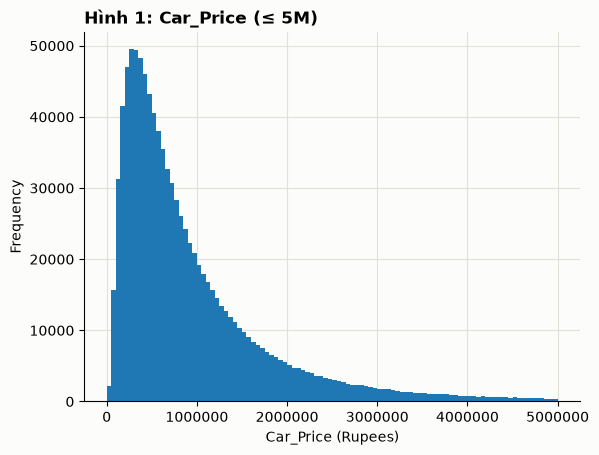

In [46]:
print("Skew Car_Price:", round(df_clean["Car_Price"].skew(), 2))
print("Tỉ lệ xe <= 5M:", round((df_clean["Car_Price"] <= 5_000_000).mean() * 100, 2), "%")

df_clean["Car_Price"].plot(kind="hist", bins=100, range=(0, 5_000_000))
plt.title("Hình 1: Car_Price (≤ 5M)")
plt.xlabel("Car_Price (Rupees)")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

In [47]:
q1, q3 = df_clean["Car_Price"].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
print("Q1:", round(q1), "| Q3:", round(q3), "| Ngưỡng outlier trên:", round(upper))
print("Số xe > ngưỡng:", (df_clean["Car_Price"] > upper).sum())
print("Trong đó Luxury:", ((df_clean["Car_Price"] > upper) & (df_clean["Segment"] == "Luxury")).sum())

Q1: 365153 | Q3: 1237770 | Ngưỡng outlier trên: 2546696
Số xe > ngưỡng: 71044
Trong đó Luxury: 16452


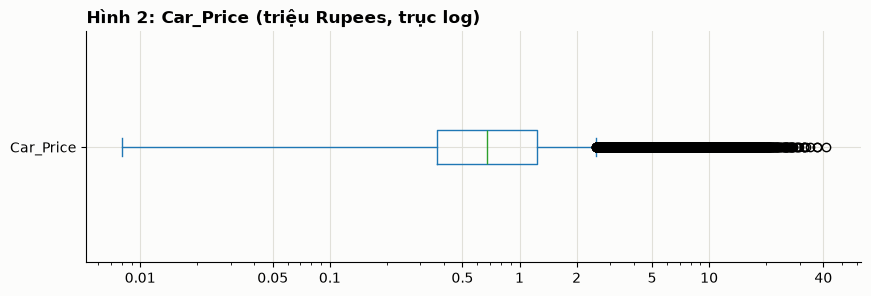

In [48]:
(df_clean["Car_Price"] / 1_000_000).plot(kind="box", vert=False, logx=True, figsize=(10, 3))
plt.xticks([0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 40], ["0.01", "0.05", "0.1", "0.5", "1", "2", "5", "10", "40"])
plt.title("Hình 2: Car_Price (triệu Rupees, trục log)")
plt.show()

Skew log(Car_Price): -0.0


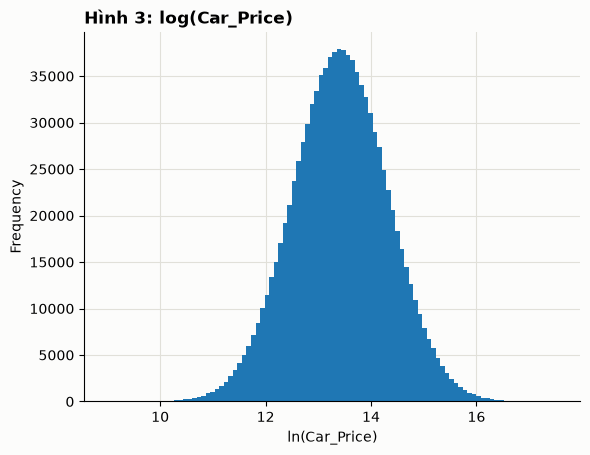

In [49]:
print("Skew log(Car_Price):", round(np.log(df_clean["Car_Price"]).skew(), 2))

np.log(df_clean["Car_Price"]).plot(kind="hist", bins=100)
plt.title("Hình 3: log(Car_Price)")
plt.xlabel("ln(Car_Price)")
plt.show()

**Phân phối Car_Price (Hình 1–3)**
- Lệch phải: mean 1,012,706 > median 671,405, skew 4.55; đuôi dài tới ~41.4M. 98.67% xe ≤ 5M nên Hình 1 chỉ vẽ tới 5M.
- Hình 1: 1 đỉnh duy nhất ở khoảng 0.25–0.3M, sau đó giảm dần; không có cột giá sàn.
- Boxplot (Hình 2): 50% xe giữa có giá 0.37M–1.24M; ngưỡng outlier trên ≈ 2.55M. 71,044 xe (7.1%) vượt ngưỡng, trong đó 16,452 là Luxury (23.2%, gần bằng tỉ lệ Luxury trong mẫu) → outlier không tập trung ở segment nào, là đuôi phải tự nhiên.
- log(Car_Price) (Hình 3): skew ≈ 0, hình chuông cân đối, 1 đỉnh → giá xấp xỉ phân phối log-normal → cân nhắc dùng log(price) cho M2.

In [50]:
print("Bảng 4 – Mean vs median của Car_Price (Rupees)")
for name, d in [("Toàn bộ", df_clean),
                ("Luxury", df_clean[df_clean["Segment"] == "Luxury"]),
                ("Non-luxury", df_clean[df_clean["Segment"] == "Non-luxury"])]:
    print(name, "| mean:", round(d["Car_Price"].mean()), "| median:", round(d["Car_Price"].median()),
          "| mean/median:", round(d["Car_Price"].mean() / d["Car_Price"].median(), 3))

Bảng 4 – Mean vs median của Car_Price (Rupees)


Toàn bộ | mean: 1012706 | median: 671405 | mean/median: 1.508
Luxury | mean: 1012767 | median: 670026 | mean/median: 1.512
Non-luxury | mean: 1012687 | median: 671791 | mean/median: 1.507


**Mean vs median (câu hỏi B-iv của Guide) – Bảng 4**
- Toàn bộ: mean 1,012,706 > median 671,405 (mean/median = 1.508) → phân phối Car_Price lệch phải: đa số xe có giá vừa phải, một số ít xe rất đắt (tới ~41.4M) kéo mean lên (Hình 1–2).
- Tỉ lệ mean/median gần như bằng nhau trong từng segment (Luxury 1.512, Non-luxury 1.507) → độ lệch là hình dạng của phân phối giá, không phải do trộn 2 segment.
- → Nên báo cáo **median** cho khách hàng (giá của "chiếc xe điển hình"); mean cao hơn median ~51% vì bị kéo bởi số ít xe cực đắt.

In [51]:
df_clean[num_cols].skew().round(2)

Car_Price           4.55
Registration_Age   -0.00
Kms_Driven          3.23
Engine_CC           0.08
Horsepower          0.05
Mileage_kmpl        0.00
Accidents           1.83
dtype: float64

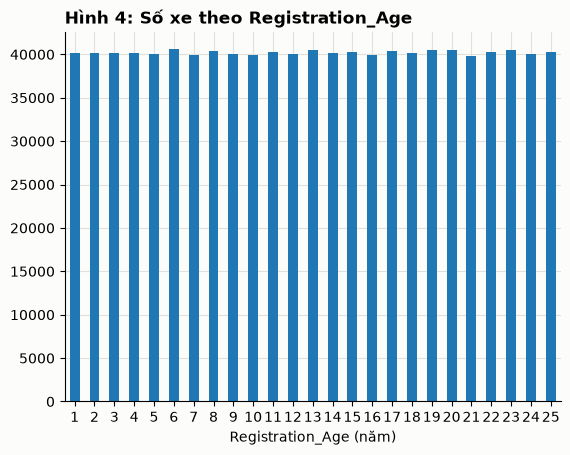

In [52]:
df_clean["Registration_Age"].value_counts().sort_index().plot(kind="bar", rot=0)
plt.title("Hình 4: Số xe theo Registration_Age")
plt.xlabel("Registration_Age (năm)")
plt.show()

Tỉ lệ xe <= 2 triệu km: 99.97 %


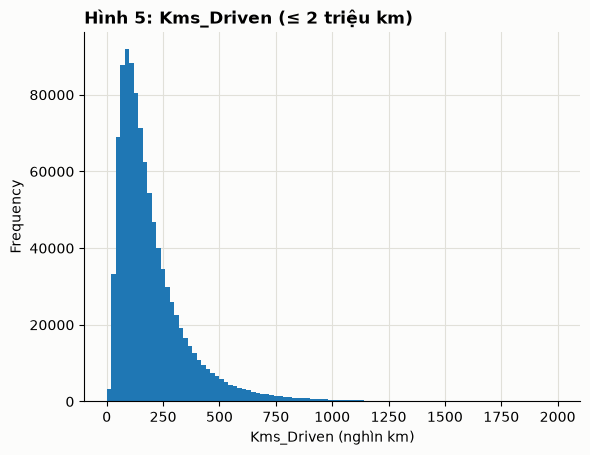

In [53]:
print("Tỉ lệ xe <= 2 triệu km:", round((df_clean["Kms_Driven"] <= 2_000_000).mean() * 100, 2), "%")

(df_clean["Kms_Driven"] / 1000).plot(kind="hist", bins=100, range=(0, 2000))
plt.title("Hình 5: Kms_Driven (≤ 2 triệu km)")
plt.xlabel("Kms_Driven (nghìn km)")
plt.show()

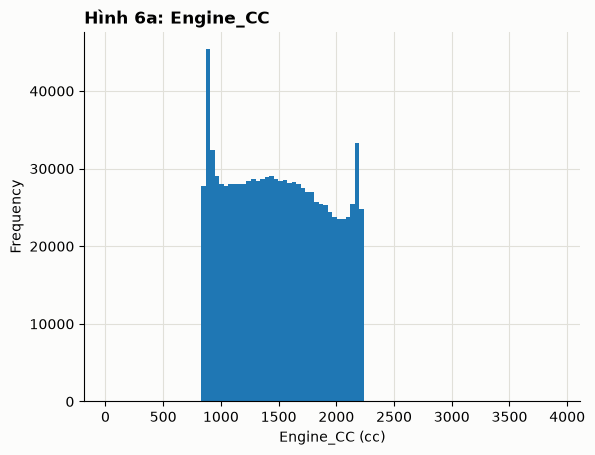

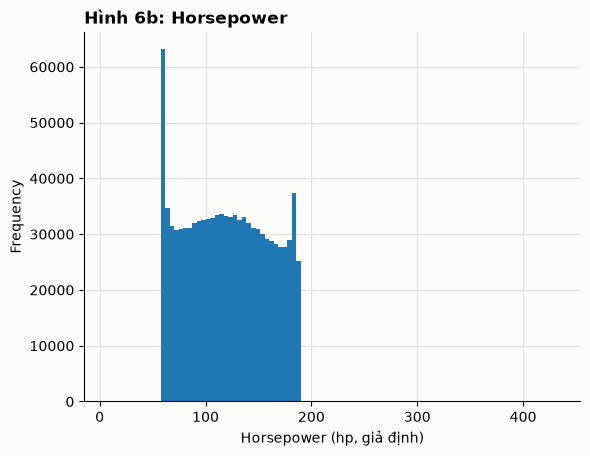

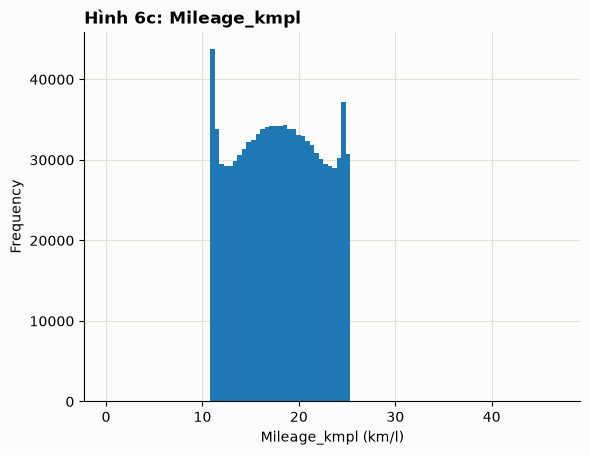

In [54]:
units_plot = {"Engine_CC": "cc", "Horsepower": "hp, giả định", "Mileage_kmpl": "km/l"}
for fig_no, col in zip(["6a", "6b", "6c"], ["Engine_CC", "Horsepower", "Mileage_kmpl"]):
    df_clean[col].plot(kind="hist", bins=100)
    plt.title("Hình " + fig_no + ": " + col)
    plt.xlabel(col + " (" + units_plot[col] + ")")
    plt.show()

In [55]:
for col in ["Engine_CC", "Horsepower", "Mileage_kmpl"]:
    s = df_clean[col]
    print(col, "| min:", round(s.min(), 2), "| P0.1:", round(s.quantile(0.001), 2),
          "| P99.9:", round(s.quantile(0.999), 2), "| max:", round(s.max(), 2))

Engine_CC | min: 10.77 | P0.1: 862.39 | P99.9: 2208.81 | max: 3917.06
Horsepower | min: 6.62 | P0.1: 57.9 | P99.9: 186.56 | max: 432.61
Mileage_kmpl | min: 0.07 | P0.1: 11.01 | P99.9: 25.01 | max: 46.84


**Phân phối các biến khác (Hình 4–6)**
- Registration_Age (Hình 4): phân bố đều từ 1–25 năm (~40k xe mỗi tuổi) → dữ liệu có dấu hiệu mô phỏng.
- Kms_Driven (Hình 5): lệch phải (skew 3.23), đỉnh ở khoảng 80–100k km, 99.97% xe ≤ 2 triệu km; max 5.22M km.
- Engine_CC, Horsepower, Mileage_kmpl (Hình 6a–6c): gần như phân bố đều trong 1 khoảng cố định, 99.8% giá trị nằm trong 862–2,209 cc, 58–187 hp, 11–25 km/l (P0.1–P99.9); 2 đầu khoảng có cột cao hơn hẳn, ngoài khoảng gần như không có xe → hình dạng này là dấu hiệu dữ liệu được tạo ngẫu nhiên (randomize).
- Ngoài khoảng chính vẫn có vài giá trị rất nhỏ / rất lớn (vd Engine_CC 10.77 → 3,917 cc) → xem phần outlier.
- Accidents: lệch phải (skew 1.83), median = 0 → đa số xe không có tai nạn.

In [56]:
for col in ["Fuel_Type", "Transmission", "Owner_Type", "Segment"]:
    print(df_clean[col].value_counts(normalize=True).mul(100).round(1))
    print("-" * 30)

Fuel_Type
Petrol      41.2
Diesel      27.7
CNG          9.0
Unknown      7.8
Electric     7.5
Hybrid       6.6
Name: proportion, dtype: float64
------------------------------
Transmission
Manual       59.8
Automatic    32.2
Unknown       8.0
Name: proportion, dtype: float64
------------------------------
Owner_Type
First      59.9
Second     25.0
Third      10.0
Fourth+     5.0
Name: proportion, dtype: float64
------------------------------
Segment
Non-luxury    76.9
Luxury        23.1
Name: proportion, dtype: float64
------------------------------


- Fuel_Type còn 6 nhóm: Petrol 41.2%, Diesel 27.7%, CNG 9.0%, Unknown 7.8%, Electric 7.5%, Hybrid 6.6%.
- Transmission: Manual 59.8%, Automatic 32.2%, Unknown 8.0%. Owner_Type: First 59.9% → Fourth+ 5.0%.
- Segment: Non-luxury 76.9%, Luxury 23.1% (≈ 3/13 hãng, vì mỗi hãng có số xe gần bằng nhau).
- Các nhóm đều ≥ 5% → không còn nhóm hiếm (các nhãn lỗi đã được gộp).

In [57]:
for col in ["Car_Price", "Kms_Driven", "Engine_CC", "Horsepower", "Mileage_kmpl"]:
    s = df_clean[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    n_iqr = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
    n_z = (((s - s.mean()) / s.std()).abs() > 3).sum()
    print(col, "| IQR 1.5x:", n_iqr, "| |z| > 3:", n_z)

Car_Price | IQR 1.5x: 71044 | |z| > 3: 18683
Kms_Driven | IQR 1.5x: 58532 | |z| > 3: 18690
Engine_CC | IQR 1.5x: 40 | |z| > 3: 58
Horsepower | IQR 1.5x: 26 | |z| > 3: 37
Mileage_kmpl | IQR 1.5x: 16 | |z| > 3: 23


In [58]:
for seg in ["Luxury", "Non-luxury"]:
    s = df_clean.loc[df_clean["Segment"] == seg, "Car_Price"]
    q1, q3 = s.quantile([0.25, 0.75])
    upper = q3 + 1.5 * (q3 - q1)
    print(seg, "| ngưỡng trên:", round(upper), "| số xe vượt:", (s > upper).sum(), "| %:", round((s > upper).mean() * 100, 2))

Luxury | ngưỡng trên: 2543637 | số xe vượt: 16497 | %: 7.11
Non-luxury | ngưỡng trên: 2547716 | số xe vượt: 54545 | %: 7.06


**Outlier sau khi làm sạch**
- Car_Price và Kms_Driven (lệch phải): IQR (1.5×) gắn cờ nhiều hơn z-score (|z| > 3): Car_Price 71,044 vs 18,683; Kms_Driven 58,532 vs 18,690 → IQR đánh dấu cả phần đuôi tự nhiên.
- Engine_CC, Horsepower, Mileage_kmpl: chỉ vài chục outlier (IQR 40 / 26 / 16; z 58 / 37 / 23), chính là những giá trị nằm tách xa khoảng chính ở Hình 6. Không có căn cứ để nói chúng sai (khác với giá trị 0) → giữ lại.
- Car_Price tính ngưỡng riêng từng segment: ngưỡng trên gần như bằng nhau (~2.54M), mỗi segment ~7.1% xe vượt ngưỡng (Luxury 16,497, Non-luxury 54,545) → outlier giá không liên quan tới segment.
- → Không xoá thêm dòng nào ở bước này. Ảnh hưởng nếu bỏ outlier giá: xem Bảng 12.

In [59]:
corr_cols = ["Registration_Age", "Kms_Driven", "Engine_CC", "Horsepower", "Mileage_kmpl",
             "Accidents", "Service_History", "Insurance_Valid", "Tax_Paid", "Seats", "Number_of_Doors"]
print("Bảng 5 – Correlation giữa các biến và Car_Price")
pd.DataFrame({
    "Pearson": df_clean[corr_cols].corrwith(df_clean["Car_Price"]),
    "Spearman": df_clean[corr_cols].corrwith(df_clean["Car_Price"], method="spearman"),
}).round(3)

Bảng 5 – Correlation giữa các biến và Car_Price


,Pearson,Spearman
Registration_Age,-0.000,-0.001
Kms_Driven,-0.050,-0.070
Engine_CC,0.029,0.035
Horsepower,0.035,0.042
Mileage_kmpl,-0.001,0.000
Accidents,-0.000,0.000
Service_History,0.000,-0.000
Insurance_Valid,0.002,0.003
Tax_Paid,-0.000,-0.001
Seats,0.002,0.002


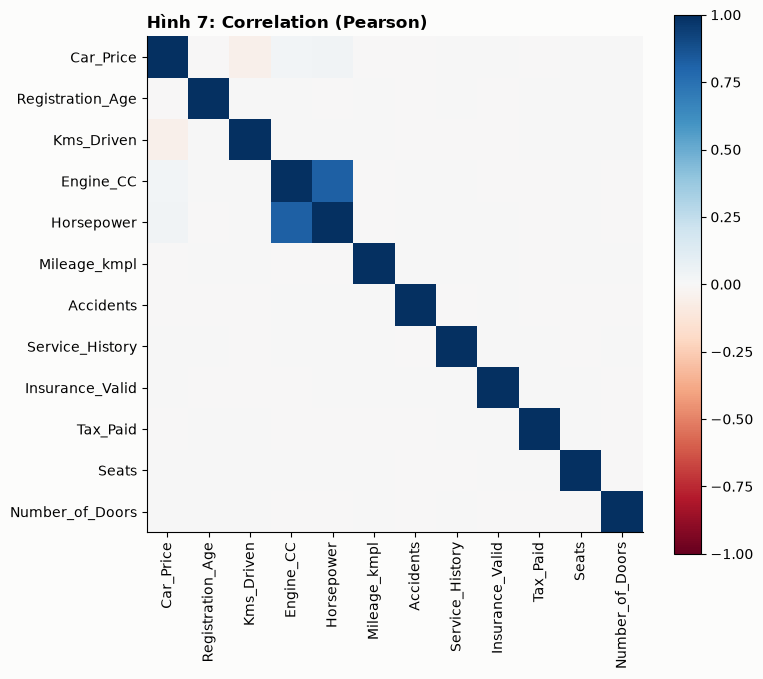

In [60]:
corr = df_clean[["Car_Price"] + corr_cols].corr()
plt.figure(figsize=(8, 7))
plt.imshow(corr, cmap="RdBu", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar()
plt.grid(False)
plt.title("Hình 7: Correlation (Pearson)")
plt.show()

In [61]:
print("Engine_CC vs Horsepower:", round(df_clean["Engine_CC"].corr(df_clean["Horsepower"]), 3))
print("Registration_Age vs Kms_Driven:", round(df_clean["Registration_Age"].corr(df_clean["Kms_Driven"]), 3))

Engine_CC vs Horsepower: 0.815
Registration_Age vs Kms_Driven: 0.0


**Correlation (Bảng 5, Hình 7)**
- Với Car_Price, mọi correlation đều rất yếu: Kms_Driven là mạnh nhất (Pearson -0.050 / Spearman -0.070), tiếp theo là Horsepower (0.035 / 0.042) và Engine_CC (0.029 / 0.035).
- Registration_Age ≈ 0 (-0.000 / -0.001) → giá không thay đổi theo tuổi xe. Mileage, Accidents, Service_History, Insurance, Tax, Seats, Doors: ≈ 0 (|r| ≤ 0.003).
- Multicollinearity (Hình 7): chỉ có 1 cặp mạnh là Engine_CC – Horsepower 0.815 → không nên đưa cả 2 vào cùng mô hình. Registration_Age – Kms_Driven = 0.0. (Year không dùng vì trùng Registration_Age.)
- → Từng biến riêng lẻ giải thích rất ít sự khác nhau về giá.

Số điểm > 6 triệu (không hiện trên hình): 33


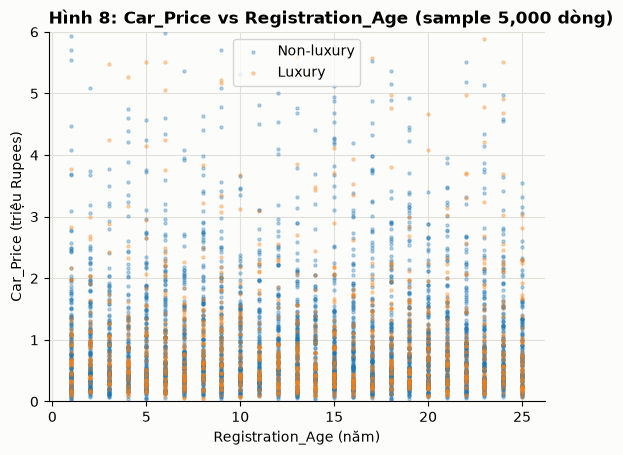

In [62]:
sample = df_clean.sample(5000, random_state=42)
print("Số điểm > 6 triệu (không hiện trên hình):", (sample["Car_Price"] > 6e6).sum())

for seg, color in [("Non-luxury", "tab:blue"), ("Luxury", "tab:orange")]:
    s = sample[sample["Segment"] == seg]
    plt.scatter(s["Registration_Age"], s["Car_Price"] / 1e6, s=5, alpha=0.3, color=color, label=seg)
plt.ylim(0, 6)
plt.title("Hình 8: Car_Price vs Registration_Age (sample 5,000 dòng)")
plt.xlabel("Registration_Age (năm)")
plt.ylabel("Car_Price (triệu Rupees)")
plt.legend()
plt.show()

Số điểm Kms > 2 triệu km (không hiện trên hình): 1


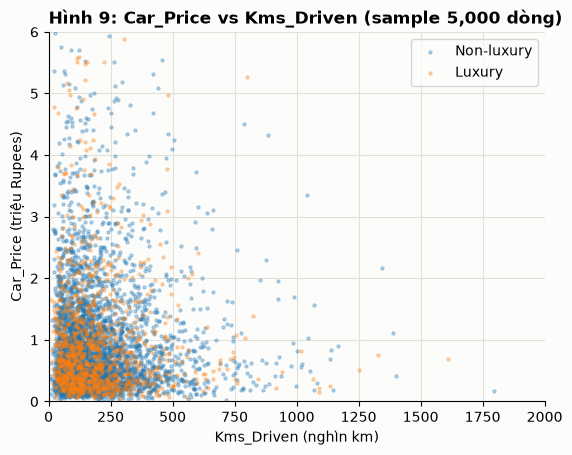

In [63]:
print("Số điểm Kms > 2 triệu km (không hiện trên hình):", (sample["Kms_Driven"] > 2_000_000).sum())

for seg, color in [("Non-luxury", "tab:blue"), ("Luxury", "tab:orange")]:
    s = sample[sample["Segment"] == seg]
    plt.scatter(s["Kms_Driven"] / 1000, s["Car_Price"] / 1e6, s=5, alpha=0.3, color=color, label=seg)
plt.xlim(0, 2000)
plt.ylim(0, 6)
plt.title("Hình 9: Car_Price vs Kms_Driven (sample 5,000 dòng)")
plt.xlabel("Kms_Driven (nghìn km)")
plt.ylabel("Car_Price (triệu Rupees)")
plt.legend()
plt.show()

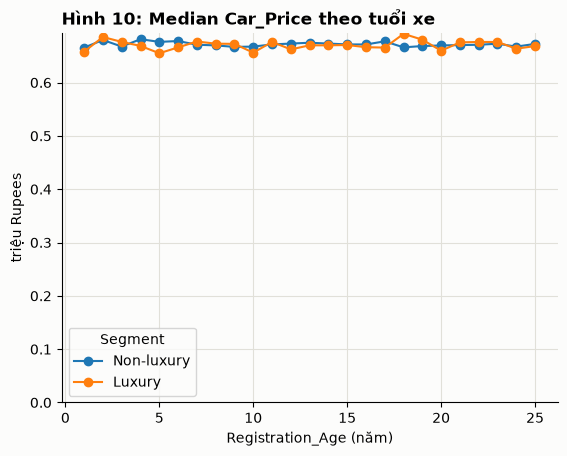

Bảng 6 – Median Car_Price theo tuổi xe (triệu Rupees)


Segment,Non-luxury,Luxury
Registration_Age,,
1,0.67,0.66
5,0.68,0.65
10,0.67,0.66
15,0.67,0.67
20,0.67,0.66
25,0.67,0.67


In [64]:
age_price = df_clean.groupby(["Registration_Age", "Segment"])["Car_Price"].median().unstack()
age_price = age_price[["Non-luxury", "Luxury"]]
(age_price / 1e6).plot(marker="o")
plt.title("Hình 10: Median Car_Price theo tuổi xe")
plt.xlabel("Registration_Age (năm)")
plt.ylabel("triệu Rupees")
plt.ylim(bottom=0)
plt.show()

print("Bảng 6 – Median Car_Price theo tuổi xe (triệu Rupees)")
(age_price.loc[[1, 5, 10, 15, 20, 25]] / 1e6).round(2)

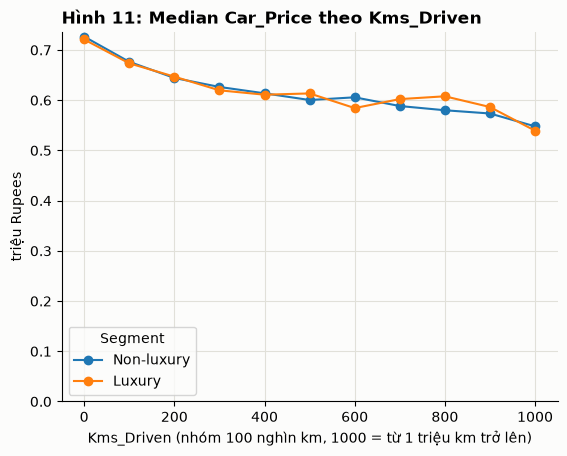

Bảng 7 – Median Car_Price theo nhóm Kms_Driven (triệu Rupees)


Segment,Non-luxury,Luxury
Kms_Driven,,
0.0,0.727,0.721
100.0,0.676,0.673
200.0,0.644,0.647
300.0,0.626,0.620
400.0,0.614,0.611
500.0,0.600,0.614
600.0,0.606,0.584
700.0,0.588,0.602
800.0,0.580,0.608


In [65]:
kms_band = df_clean["Kms_Driven"].clip(upper=1_000_000) // 100_000 * 100
kms_price = df_clean.groupby([kms_band, "Segment"])["Car_Price"].median().unstack()
kms_price = kms_price[["Non-luxury", "Luxury"]]
(kms_price / 1e6).plot(marker="o")
plt.title("Hình 11: Median Car_Price theo Kms_Driven")
plt.xlabel("Kms_Driven (nhóm 100 nghìn km, 1000 = từ 1 triệu km trở lên)")
plt.ylabel("triệu Rupees")
plt.ylim(bottom=0)
plt.show()

print("Bảng 7 – Median Car_Price theo nhóm Kms_Driven (triệu Rupees)")
(kms_price / 1e6).round(3)

**Giá theo tuổi xe và Kms_Driven (câu hỏi 1 của Guide) – Hình 8–11, Bảng 6–7**
- Cách làm: vẽ ~1 triệu điểm thì không đọc được → scatter trên sample ngẫu nhiên 5,000 dòng, random_state=42 (Hình 8–9), kèm median theo nhóm tính trên toàn bộ df_clean (Hình 10–11). Trục y của scatter cắt ở 6 triệu Rupees (ẩn 33 điểm); trục x của Hình 9 cắt ở 2 triệu km (ẩn 1 điểm).
- Hình 8: ở mọi tuổi xe, giá trải từ gần 0 tới ~6M như nhau, 2 segment chồng lên nhau → không thấy xu hướng.
- Median theo tuổi (Hình 10, Bảng 6): nằm ngang ở khoảng 0.65–0.69M từ tuổi 1 tới 25, ở cả 2 segment → giá không giảm theo tuổi xe.
- Hình 9: phần lớn xe < 500k km; xe chạy nhiều có ít điểm giá cao hơn.
- Median theo Kms (Hình 11, Bảng 7): giảm dần từ ~0.73M (< 100k km) → ~0.61M (400k–500k km) → ~0.55M (≥ 1 triệu km), tức giảm khoảng 25%; 2 segment gần như trùng nhau → quan hệ âm nhưng yếu (Spearman -0.07).

In [66]:
for col in ["Fuel_Type", "Transmission", "Owner_Type"]:
    print(pd.crosstab(df_clean["Segment"], df_clean[col], normalize="index").mul(100).round(1))
    print("-" * 30)

Fuel_Type   CNG  Diesel  Electric  Hybrid  Petrol  Unknown
Segment                                                   
Luxury      9.0    27.8       7.5     6.7    41.2      7.8
Non-luxury  9.0    27.7       7.6     6.6    41.2      7.8
------------------------------
Transmission  Automatic  Manual  Unknown
Segment                                 
Luxury             32.2    59.7      8.1
Non-luxury         32.2    59.8      8.0
------------------------------
Owner_Type  First  Fourth+  Second  Third
Segment                                  
Luxury       59.9      5.1    25.0   10.0
Non-luxury   59.9      5.0    25.1   10.0
------------------------------


- Cơ cấu Fuel_Type, Transmission, Owner_Type gần như giống hệt nhau giữa 2 segment (chênh ≤ 0.1 điểm %), vd Petrol 41.2% ở cả 2 nhóm, Manual 59.7% vs 59.8%.
- → 2 segment có cùng "hồ sơ xe" về nhiên liệu, hộp số và số đời chủ.

In [67]:
for col in ["Fuel_Type", "Transmission", "Owner_Type", "Color", "City", "Accidents",
            "Service_History", "Insurance_Valid", "Tax_Paid", "Seats", "Number_of_Doors"]:
    m = df_clean.groupby(col)["Car_Price"].median()
    print(col, ":", round(m.min()), "->", round(m.max()), "| max/min =", round(m.max() / m.min(), 2))

Fuel_Type : 667645 -> 673214 | max/min = 1.01


Transmission : 670089 -> 672136 | max/min = 1.0
Owner_Type : 667905 -> 673065 | max/min = 1.01
Color : 666677 -> 675037 | max/min = 1.01
City : 667761 -> 674149 | max/min = 1.01


Accidents : 622499 -> 1275716 | max/min = 2.05
Service_History : 671090 -> 672117 | max/min = 1.0
Insurance_Valid : 665913 -> 672440 | max/min = 1.01


Tax_Paid : 670795 -> 676316 | max/min = 1.01
Seats : 667141 -> 673884 | max/min = 1.01
Number_of_Doors : 670762 -> 672927 | max/min = 1.0


In [68]:
print("Bảng 8 – Số xe (trên) và median Car_Price (Rupees, dưới) theo Accidents × Segment")
print(pd.crosstab(df_clean["Accidents"], df_clean["Segment"]))
df_clean.groupby(["Accidents", "Segment"])["Car_Price"].median().unstack().round()

Bảng 8 – Số xe (trên) và median Car_Price (Rupees, dưới) theo Accidents × Segment
Segment    Luxury  Non-luxury
Accidents                    
0          171854      573124
1           51760      171195
2            7760       25674
3             740        2655
4              55         167
5               3          13


Segment,Luxury,Non-luxury
Accidents,,
0,670249.0,671430.0
1,669424.0,673233.0
2,666481.0,670120.0
3,689328.0,676706.0
4,564534.0,627572.0
5,848515.0,1508308.0


In [69]:
print("Bảng 9 – Median Car_Price (Rupees) theo Service_History × Segment")
df_clean.groupby(["Service_History", "Segment"])["Car_Price"].median().unstack().round()

Bảng 9 – Median Car_Price (Rupees) theo Service_History × Segment


Segment,Luxury,Non-luxury
Service_History,,
0,670529.0,672462.0
1,669812.0,671541.0


**Giá theo các biến khác (Bảng 8–9)**
- Fuel_Type, Transmission, Owner_Type, Color, City, Service_History, Insurance_Valid, Tax_Paid, Seats, Number_of_Doors: median giữa các nhóm chênh ≤ 1% (max/min ≤ 1.01) → không ảnh hưởng tới giá.
- Service_History (Bảng 9): median ~670–672k ở cả 2 mức, cả 2 segment.
- Accidents (Bảng 8): 0–3 vụ có median ~666–689k, không có xu hướng. Nhóm 4–5 vụ có rất ít xe (5 vụ: 3 Luxury, 13 Non-luxury) → median không ổn định (max/min = 2.05 là do nhóm này).
- → Không có biến chữ / rời rạc nào liên quan rõ tới giá; chỉ còn Kms_Driven, Engine_CC, Horsepower có quan hệ yếu (Bảng 5).

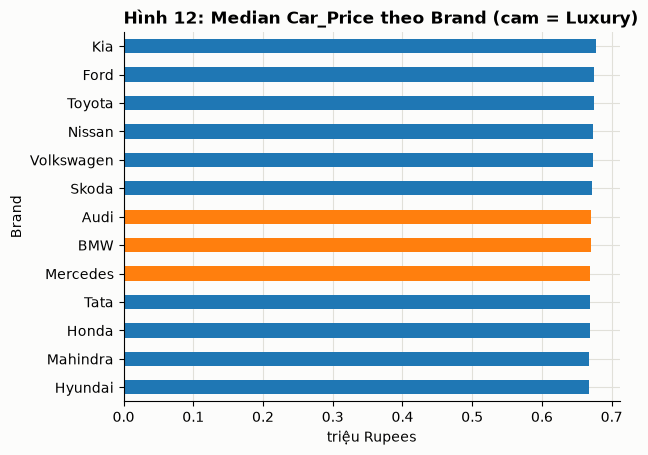

Bảng 10 – Median Car_Price theo Brand (triệu Rupees)


Brand
Kia           0.68
Hyundai       0.67
Mahindra      0.67
Honda         0.67
Tata          0.67
Mercedes      0.67
BMW           0.67
Audi          0.67
Skoda         0.67
Volkswagen    0.67
Nissan        0.67
Toyota        0.67
Ford          0.67
Name: Car_Price, dtype: float64

In [70]:
brand_price = df_clean.groupby("Brand")["Car_Price"].median().sort_values()
colors = ["tab:orange" if b in lux else "tab:blue" for b in brand_price.index]
(brand_price / 1e6).plot(kind="barh", color=colors)
plt.title("Hình 12: Median Car_Price theo Brand (cam = Luxury)")
plt.xlabel("triệu Rupees")
plt.show()

print("Bảng 10 – Median Car_Price theo Brand (triệu Rupees)")
(brand_price / 1e6).round(2).sort_values(ascending=False)

In [71]:
model_price = df_clean.groupby(["Brand", "Model"])["Car_Price"].median()
(model_price.groupby("Brand").max() / model_price.groupby("Brand").min()).round(3).sort_values()

Brand
Tata          1.003
Ford          1.005
Kia           1.007
Toyota        1.007
Nissan        1.011
Mahindra      1.012
Volkswagen    1.013
Honda         1.015
Skoda         1.018
Mercedes      1.019
Audi          1.020
Hyundai       1.020
BMW           1.022
Name: Car_Price, dtype: float64

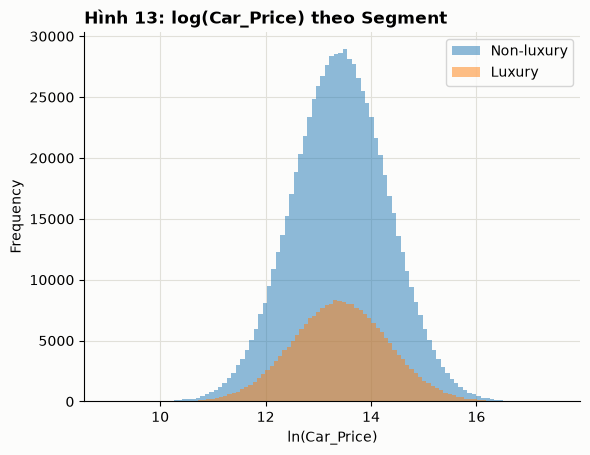

In [72]:
for seg in ["Non-luxury", "Luxury"]:
    np.log(df_clean.loc[df_clean["Segment"] == seg, "Car_Price"]).plot(kind="hist", bins=100, alpha=0.5, label=seg)
plt.title("Hình 13: log(Car_Price) theo Segment")
plt.xlabel("ln(Car_Price)")
plt.legend()
plt.show()

In [73]:
print("Bảng 11 – Car_Price (Rupees) theo Segment")
df_clean.groupby("Segment")["Car_Price"].describe().round()

Bảng 11 – Car_Price (Rupees) theo Segment


,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
Luxury,232172.0,1012767.0,1138651.0,13441.0,364895.0,670026.0,1236392.0,41442181.0
Non-luxury,772828.0,1012687.0,1139536.0,7987.0,365218.0,671791.0,1238217.0,37227010.0


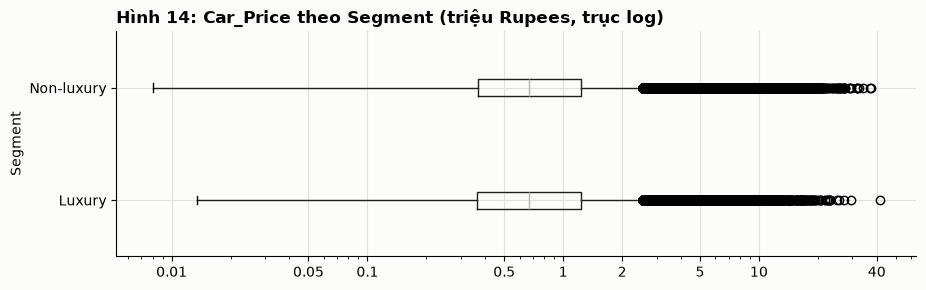

In [74]:
df_clean.boxplot(column="Car_Price", by="Segment", vert=False, figsize=(10, 3))
plt.xscale("log")
plt.xticks([1e4, 5e4, 1e5, 5e5, 1e6, 2e6, 5e6, 1e7, 4e7], ["0.01", "0.05", "0.1", "0.5", "1", "2", "5", "10", "40"])
plt.suptitle("")
plt.title("Hình 14: Car_Price theo Segment (triệu Rupees, trục log)")
plt.show()

**Ảnh hưởng của Segment (câu hỏi 2 của Guide) – Hình 12–14, Bảng 10–11**
- Median theo Brand (Hình 12, Bảng 10): cả 13 hãng đều ở 0.67–0.68M; 3 hãng Luxury (Audi, BMW, Mercedes) nằm lẫn giữa các hãng Non-luxury.
- Trong cùng 1 Brand, median giữa các Model chênh ≤ 2.2% (BMW 1.022) → Model cũng không tạo khác biệt.
- log(Car_Price) (Hình 13): 2 segment có cùng hình dạng và cùng vị trí; cột Luxury thấp hơn chỉ vì ít xe hơn.
- Bảng 11, Hình 14: Q1 365k vs 365k, median 670k vs 672k, Q3 1.236M vs 1.238M → 2 hộp gần như trùng khít.
- → Trong file này, Segment không ảnh hưởng tới giá: median Luxury / Non-luxury = 0.997.

In [75]:
for seg in ["Luxury", "Non-luxury"]:
    d = df_clean[df_clean["Segment"] == seg]
    print(seg, "| corr(giá, tuổi):", round(d["Car_Price"].corr(d["Registration_Age"]), 3),
          "| corr(giá, km):", round(d["Car_Price"].corr(d["Kms_Driven"]), 3))

Luxury | corr(giá, tuổi): 0.0 | corr(giá, km): -0.05
Non-luxury | corr(giá, tuổi): -0.001 | corr(giá, km): -0.05


In [76]:
print("Median giảm trung bình mỗi năm (tuổi 1 -> 20):")
print(((age_price.loc[1] - age_price.loc[20]) / 19).round())
print("Median ở tuổi 20 so với tuổi 1 (%):")
print((age_price.loc[20] / age_price.loc[1] * 100).round(1))

Median giảm trung bình mỗi năm (tuổi 1 -> 20):
Segment
Non-luxury   -211.0
Luxury        -90.0
dtype: float64
Median ở tuổi 20 so với tuổi 1 (%):
Segment
Non-luxury    100.6
Luxury        100.3
dtype: float64


**Giá theo tuổi / km trong từng segment**
- Correlation giá – tuổi: Luxury 0.000, Non-luxury -0.001; giá – km: -0.05 ở cả 2 → quan hệ giống nhau giữa 2 segment.
- Từ tuổi 1 → 20, median không giảm mà còn tăng rất nhẹ (~90 Rupees/năm ở Luxury, ~211 Rupees/năm ở Non-luxury); median ở tuổi 20 bằng 100.3% (Luxury) và 100.6% (Non-luxury) của tuổi 1.
- Hình 11: 2 đường theo Kms gần như trùng nhau → không thấy dấu hiệu interaction Segment × tuổi hay Segment × km.

In [77]:
df_clean.groupby("City")["Car_Price"].agg(["count", "median"]).round()

,count,median
City,,
Ahmedabad,115480,672417.0
Bangalore,115471,674149.0
Chennai,114996,671045.0
Delhi,115999,671544.0
Hyderabad,115854,667772.0
Kolkata,115405,672578.0
Mumbai,115777,673292.0
Pune,115588,671041.0
Unknown,80430,667761.0


In [78]:
pd.crosstab(df_clean["City"], df_clean["Segment"], normalize="index").mul(100).round(1)

Segment,Luxury,Non-luxury
City,,
Ahmedabad,23.2,76.8
Bangalore,23.0,77.0
Chennai,23.1,76.9
Delhi,23.1,76.9
Hyderabad,23.0,77.0
Kolkata,23.1,76.9
Mumbai,23.2,76.8
Pune,23.1,76.9
Unknown,23.2,76.8


**City và tính đại diện của mẫu**
- Median giá giữa 8 city chỉ chênh ~1% (668k – 674k); nhóm City = Unknown cũng tương tự (668k) → City không ảnh hưởng tới giá.
- Tỉ lệ Luxury ở mọi city ~23.0–23.2% → segment phân bố đều theo city.
- Mỗi city có ~115–116k xe (Unknown ~80k) → mẫu được chia đều theo city (và theo brand, theo năm) → không phản ánh quy mô thị trường thật, cần nêu khi khái quát hoá.

In [79]:
q1, q3 = df_clean["Car_Price"].quantile([0.25, 0.75])
price_upper = q3 + 1.5 * (q3 - q1)

print("Bảng 12 – Độ nhạy của kết quả theo cách xử lý dữ liệu")
for name, d in [("Đang dùng: giữ tất cả dòng", df_clean),
                ("Loại Kms > 1,000,000 (ví dụ trong Guide)", df_clean[df_clean["Kms_Driven"] <= 1_000_000]),
                ("Loại dòng trùng ở các cột không bị randomize", df_clean.drop_duplicates(subset=other_cols)),
                ("Loại outlier Car_Price (IQR toàn mẫu)", df_clean[df_clean["Car_Price"] <= price_upper])]:
    med_lux = d.loc[d["Segment"] == "Luxury", "Car_Price"].median()
    med_non = d.loc[d["Segment"] == "Non-luxury", "Car_Price"].median()
    print(name)
    print("   số dòng:", len(d), "| median Luxury:", round(med_lux), "| median Non-luxury:", round(med_non),
          "| Luxury / Non-luxury:", round(med_lux / med_non, 3))
    print("   Spearman(giá, km):", round(d["Car_Price"].corr(d["Kms_Driven"], method="spearman"), 3),
          "| Spearman(giá, tuổi):", round(d["Car_Price"].corr(d["Registration_Age"], method="spearman"), 3))

Bảng 12 – Độ nhạy của kết quả theo cách xử lý dữ liệu


Đang dùng: giữ tất cả dòng
   số dòng: 1005000 | median Luxury: 670026 | median Non-luxury: 671791 | Luxury / Non-luxury: 0.997


   Spearman(giá, km): -0.07 | Spearman(giá, tuổi): -0.001
Loại Kms > 1,000,000 (ví dụ trong Guide)
   số dòng: 998894 | median Luxury: 670974 | median Non-luxury: 672576 | Luxury / Non-luxury: 0.998


   Spearman(giá, km): -0.068 | Spearman(giá, tuổi): -0.001
Loại dòng trùng ở các cột không bị randomize
   số dòng: 975360 | median Luxury: 670107 | median Non-luxury: 672006 | Luxury / Non-luxury: 0.997


   Spearman(giá, km): -0.07 | Spearman(giá, tuổi): -0.0
Loại outlier Car_Price (IQR toàn mẫu)
   số dòng: 933956 | median Luxury: 618839 | median Non-luxury: 619933 | Luxury / Non-luxury: 0.998


   Spearman(giá, km): -0.061 | Spearman(giá, tuổi): -0.001


**Độ không chắc chắn (uncertainties) – Bảng 1, Bảng 12**
- Dữ liệu đã randomize (ô B6, Bảng 1): 5 cột Mileage_kmpl, Engine_CC, Horsepower, Kms_Driven, Car_Price là giá trị do macro tạo ra → kết quả về giá chỉ đúng cho bản randomize này. Các dấu hiệu cho thấy dữ liệu không phản ánh thị trường thật: Kms không tăng theo tuổi xe (corr 0.0), Engine/HP/Mileage phân bố đều trong 1 khoảng cố định (Hình 6).
- Đơn vị giả định (Bảng 1): Horsepower (hp), Kms_Driven (km), Registration_Age (năm), ý nghĩa giá trị 1 của các biến 0/1; năm tham chiếu 2025 suy ra từ Year + Registration_Age (không có ngày đăng tin).
- Giá trị 0 → NaN (41 ô): không biết giá trị thật, nhưng số lượng rất nhỏ. Các giá trị rất nhỏ nhưng > 0 (Engine_CC 10.77 cc, Horsepower 6.62, Mileage 0.07 km/l) vẫn giữ vì không có ngưỡng rõ ràng.
- 'Unknown' (~8% mỗi cột Fuel_Type / Transmission / Color / City; 28.2% dòng): giữ như 1 nhóm riêng; không biết nhãn thật, nhưng không liên quan tới giá.
- Dòng trùng ở 15 cột không bị randomize: không biết là listing lặp hay 2 xe khác nhau. Sau khi chuẩn hoá nhãn, bỏ trùng sẽ mất 29,640 dòng. Bảng 12: median gần như không đổi (Luxury 670,026 → 670,107), tỉ lệ Luxury / Non-luxury vẫn 0.997.
- Ngưỡng Kms: giữ Kms > 1M (đang dùng) hay loại theo ví dụ trong Guide (6,106 dòng). Bảng 12: median Luxury 670,026 → 670,974, Spearman(giá, km) -0.070 → -0.068 → gần như không đổi.
- Outlier Car_Price: nếu bỏ 71,044 xe vượt ngưỡng IQR (Bảng 12), median cả 2 segment giảm ~7.7% (vd Luxury 670,026 → 618,839) nhưng tỉ lệ Luxury / Non-luxury vẫn ~1.00 → mức giá phụ thuộc cách xử lý outlier, còn kết luận so sánh 2 segment thì không.
- Mode của biến liên tục không ổn định (Bảng 3a–3c) → không dùng mode để mô tả giá / km.

**Tổng kết EDA**

**Phát hiện chính**
1. Car_Price lệch phải: mean 1,012,706 > median 671,405 (mean/median 1.51, skew 4.55; Bảng 4, Hình 1–2) → báo cáo median cho khách hàng. log(Car_Price) gần như đối xứng (Hình 3) → cân nhắc log(price) khi phân tích.
2. Segment không tạo khác biệt về giá: median Luxury 670,026 vs Non-luxury 671,791 (tỉ lệ 0.997); 13 hãng đều ở 0.67–0.68M (Bảng 3a–3c, 10–11, Hình 12–14). 2 segment cũng có cùng "hồ sơ xe" (tuổi, km, nhiên liệu, hộp số…).
3. Giá không thay đổi theo tuổi xe (Spearman -0.001; median 0.65–0.69M ở mọi tuổi; Hình 8, 10, Bảng 6).
4. Giá giảm nhẹ theo Kms_Driven (Spearman -0.07): median từ ~0.73M (< 100k km) xuống ~0.55M (≥ 1 triệu km), giống nhau ở 2 segment (Hình 9, 11, Bảng 7).
5. Engine_CC và Horsepower có quan hệ dương rất yếu với giá (Spearman 0.035 / 0.042) và tương quan mạnh với nhau (0.815) → lưu ý multicollinearity (Hình 7). Kms và tuổi xe không tương quan (0.0).
6. Fuel, Transmission, Owner, Color, City, Accidents, Service_History, Insurance, Tax, Seats, Doors không ảnh hưởng tới giá (median chênh ≤ 1%, trừ nhóm Accidents rất nhỏ; Bảng 8–9).
7. Lỗi dữ liệu đã xử lý (Bảng 2): nhãn không thống nhất (Brand, Fuel_Type), 41 giá trị 0 → NaN. Giữ lại: 'Unknown' (28.2% dòng) vì ngẫu nhiên, Kms > 1M (0.61%) vì là đuôi tự nhiên, dòng trùng ở 15 cột không bị randomize vì không chắc là lặp. Không có dòng nào bị xoá.

**Hypothesis gợi ý cho M2**
- H1: Mean Car_Price của Luxury và Non-luxury không khác nhau (EDA: median 0.997 lần).
- H2: Car_Price không có quan hệ tuyến tính với Registration_Age (hệ số = 0).
- H3: Car_Price có quan hệ âm với Kms_Driven (yếu) – có ý nghĩa thống kê hay không, và mức độ có đáng kể về thực tế hay không.
- H4: Engine_CC (hoặc Horsepower) có quan hệ dương với Car_Price – chỉ đưa 1 trong 2 biến.
- H5: Ảnh hưởng của Kms_Driven giống nhau ở 2 segment (không có interaction).

**Hạn chế (cho Objective 2)**
- Dữ liệu đã randomize: 5 cột số là giá trị ngẫu nhiên → kết quả không nhất thiết phản ánh thị trường thật, và file khác sẽ cho số khác.
- Độ không chắc chắn (đơn vị giả định, giá trị 0, 'Unknown', dòng trùng, ngưỡng Kms, outlier giá) và mức ảnh hưởng: xem notes "Độ không chắc chắn" và Bảng 12.
- Kms_Driven không tăng theo tuổi xe → không kiểm tra được tính hợp lý của Kms theo tuổi.
- Mẫu chia đều theo brand, city, năm sản xuất → không phản ánh cơ cấu thị trường thật.
- Không có ngày đăng tin → không phân tích được xu hướng theo thời gian; chỉ có 13 brand, 39 model, 8 city.
- Hầu hết các biến gần như không liên quan tới giá → mô hình ở M2 nhiều khả năng giải thích được rất ít biến động của giá.

**Cần quyết định**
- Kms > 1,000,000: giữ (đang dùng) hay loại theo ví dụ trong Guide – Bảng 12 cho thấy kết quả gần như không đổi.
- Dòng trùng ở 15 cột không bị randomize: giữ (đang dùng) hay xoá.
- Các giá trị rất nhỏ nhưng > 0 của Engine_CC / Horsepower / Mileage_kmpl: giữ (đang dùng) hay đổi thành NaN.
- Dùng price hay log(price) cho M2.
- Chọn biến: Registration_Age (không dùng Year), 1 trong Engine_CC / Horsepower, Segment hay Brand.